## 1.Loan Amount Prediction

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datasets/loan_train.csv")

print("Head (First 5 rows):\n")
df.head()

Head (First 5 rows):



,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [284]:
print("Shape:", df.shape)

print("Info:")
df.info()

Shape: (30000, 24)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  obje

In [285]:

print("Describe:")
df.describe()

Describe:


,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,30000.000000,2.542400e+04,30000.000000,29828.000000,27507.000000,28297.000000,30000.000000,30000.000000,2.515000e+04,30000.000000,30000.000000,3.000000e+04,29660.000000
mean,40.092300,2.630574e+03,88826.333855,400.936876,2.253027,739.885381,0.193933,501.934700,2.631119e+03,2.460067,-4.743867,1.317597e+05,47649.342208
std,16.045129,1.126272e+04,59536.949605,242.545375,0.951162,72.163846,0.395384,288.158086,1.132268e+04,1.118562,74.614593,9.354955e+04,48221.146686
min,18.000000,3.777000e+02,6048.240000,-999.000000,1.000000,580.000000,0.000000,1.000000,3.777000e+02,1.000000,-999.000000,-9.990000e+02,-999.000000
25%,25.000000,1.650457e+03,41177.755000,247.667500,2.000000,681.880000,0.000000,251.000000,1.650450e+03,1.000000,1.000000,6.057216e+04,0.000000
50%,40.000000,2.222435e+03,75128.075000,375.205000,2.000000,739.820000,0.000000,504.000000,2.223250e+03,2.000000,1.000000,1.099936e+05,35209.395000
75%,55.000000,3.090593e+03,119964.605000,521.292500,3.000000,799.120000,0.000000,751.000000,3.091408e+03,3.000000,1.000000,1.788807e+05,74261.250000
max,65.000000,1.777460e+06,621497.820000,3840.880000,14.000000,896.260000,1.000000,999.000000,1.777460e+06,4.000000,1.000000,1.077967e+06,481907.320000


In [286]:

print("Null content count:")
df.isnull().sum()

Null content count:


Customer ID                       0
Name                              0
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property ID                       0
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64

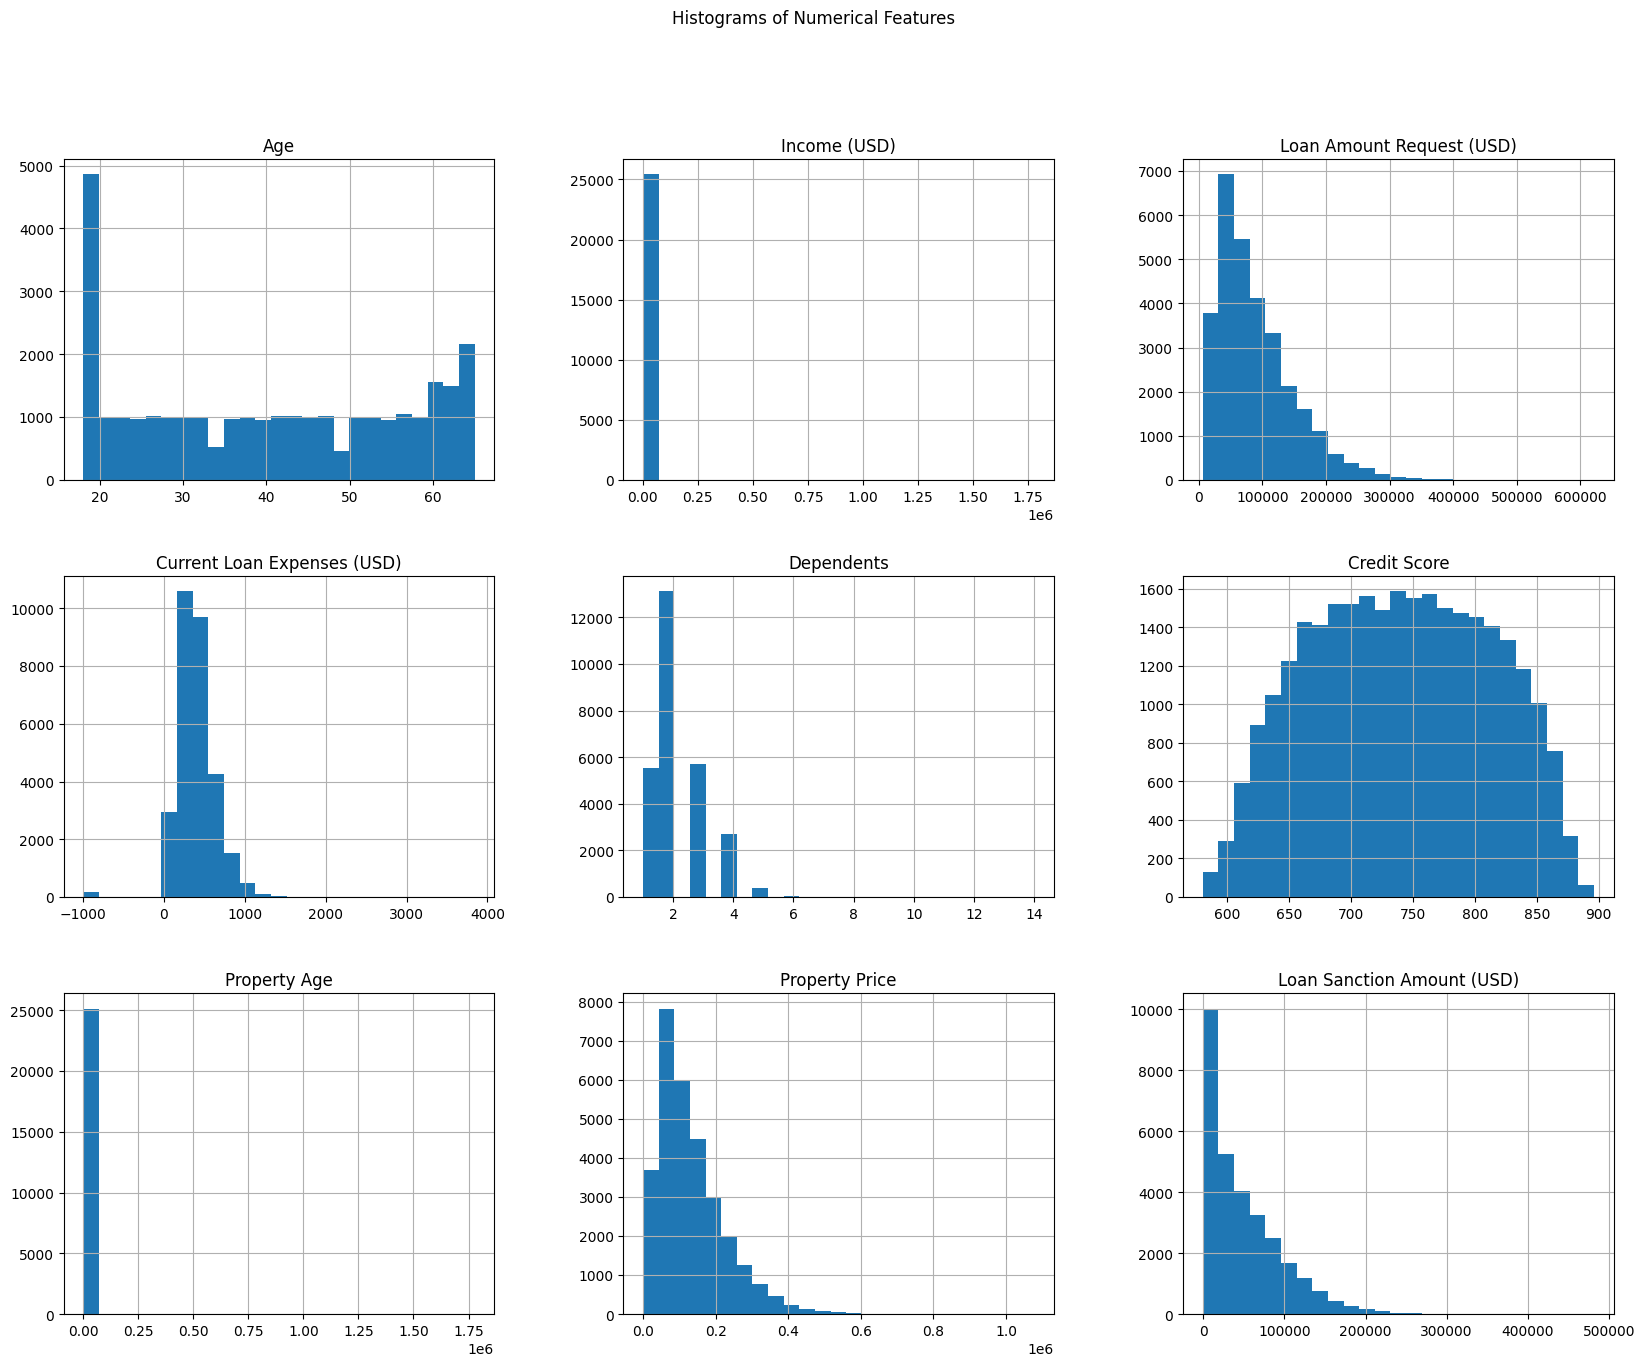

In [287]:
numcols = ['Age', 'Income (USD)', 'Loan Amount Request (USD)',
'Current Loan Expenses (USD)','Dependents', 'Credit Score','Property Age',
'Property Price', 'Loan Sanction Amount (USD)']

df[numcols].hist(figsize=(20,15),bins = 25)
plt.suptitle("Histograms of Numerical Features")
plt.show()


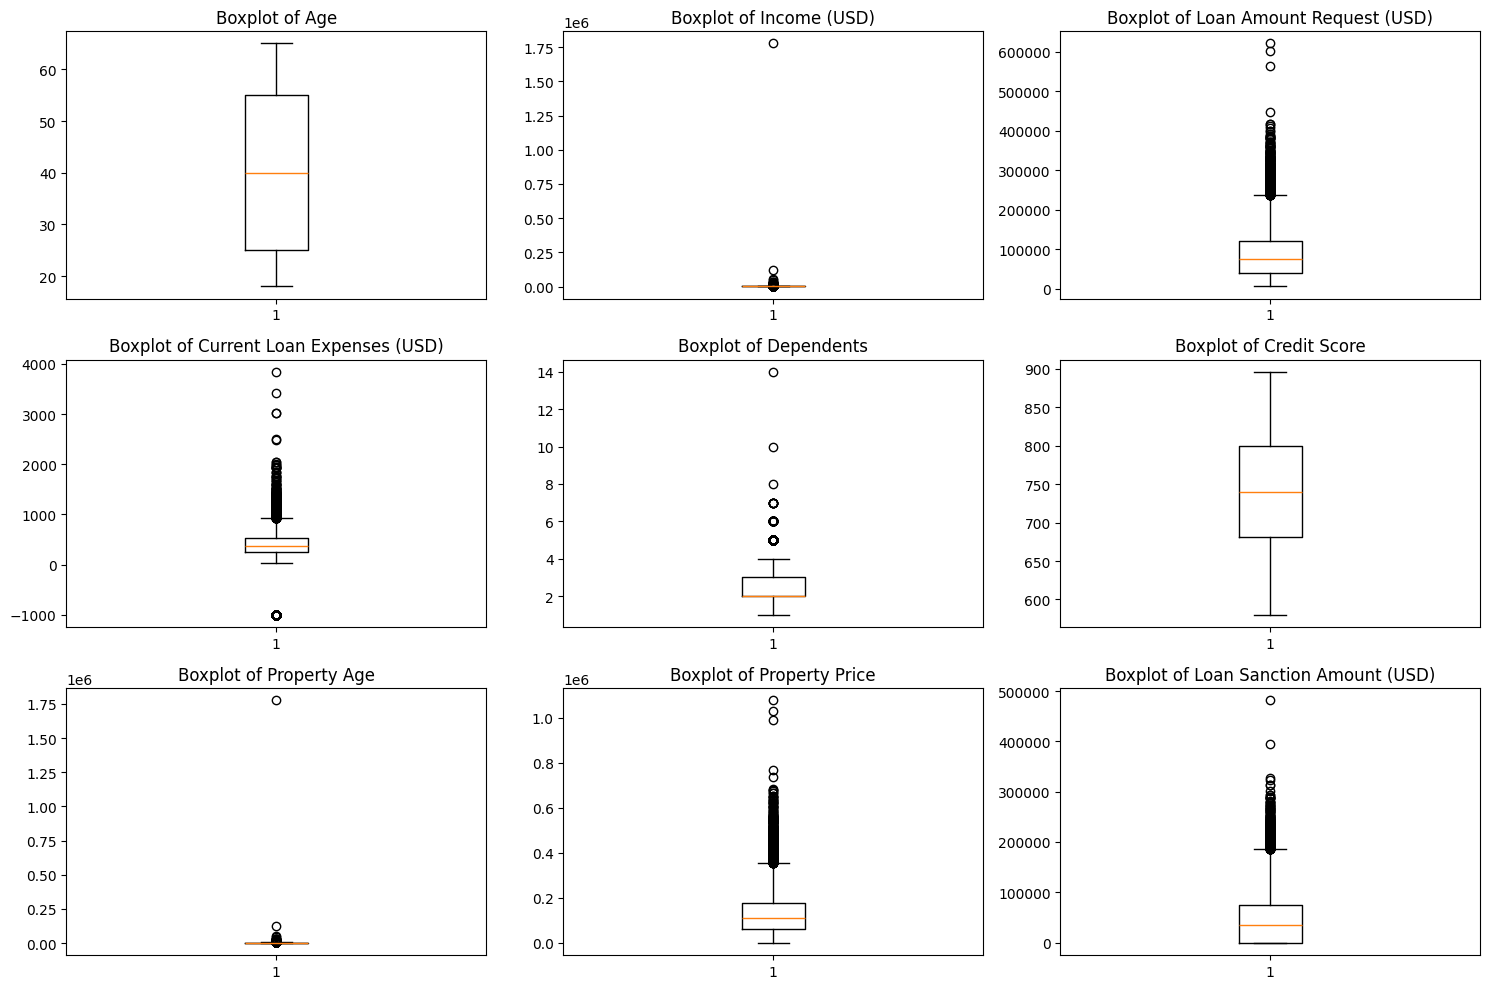

In [288]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, numcols):
    ax.boxplot(df[col].dropna())
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Count')

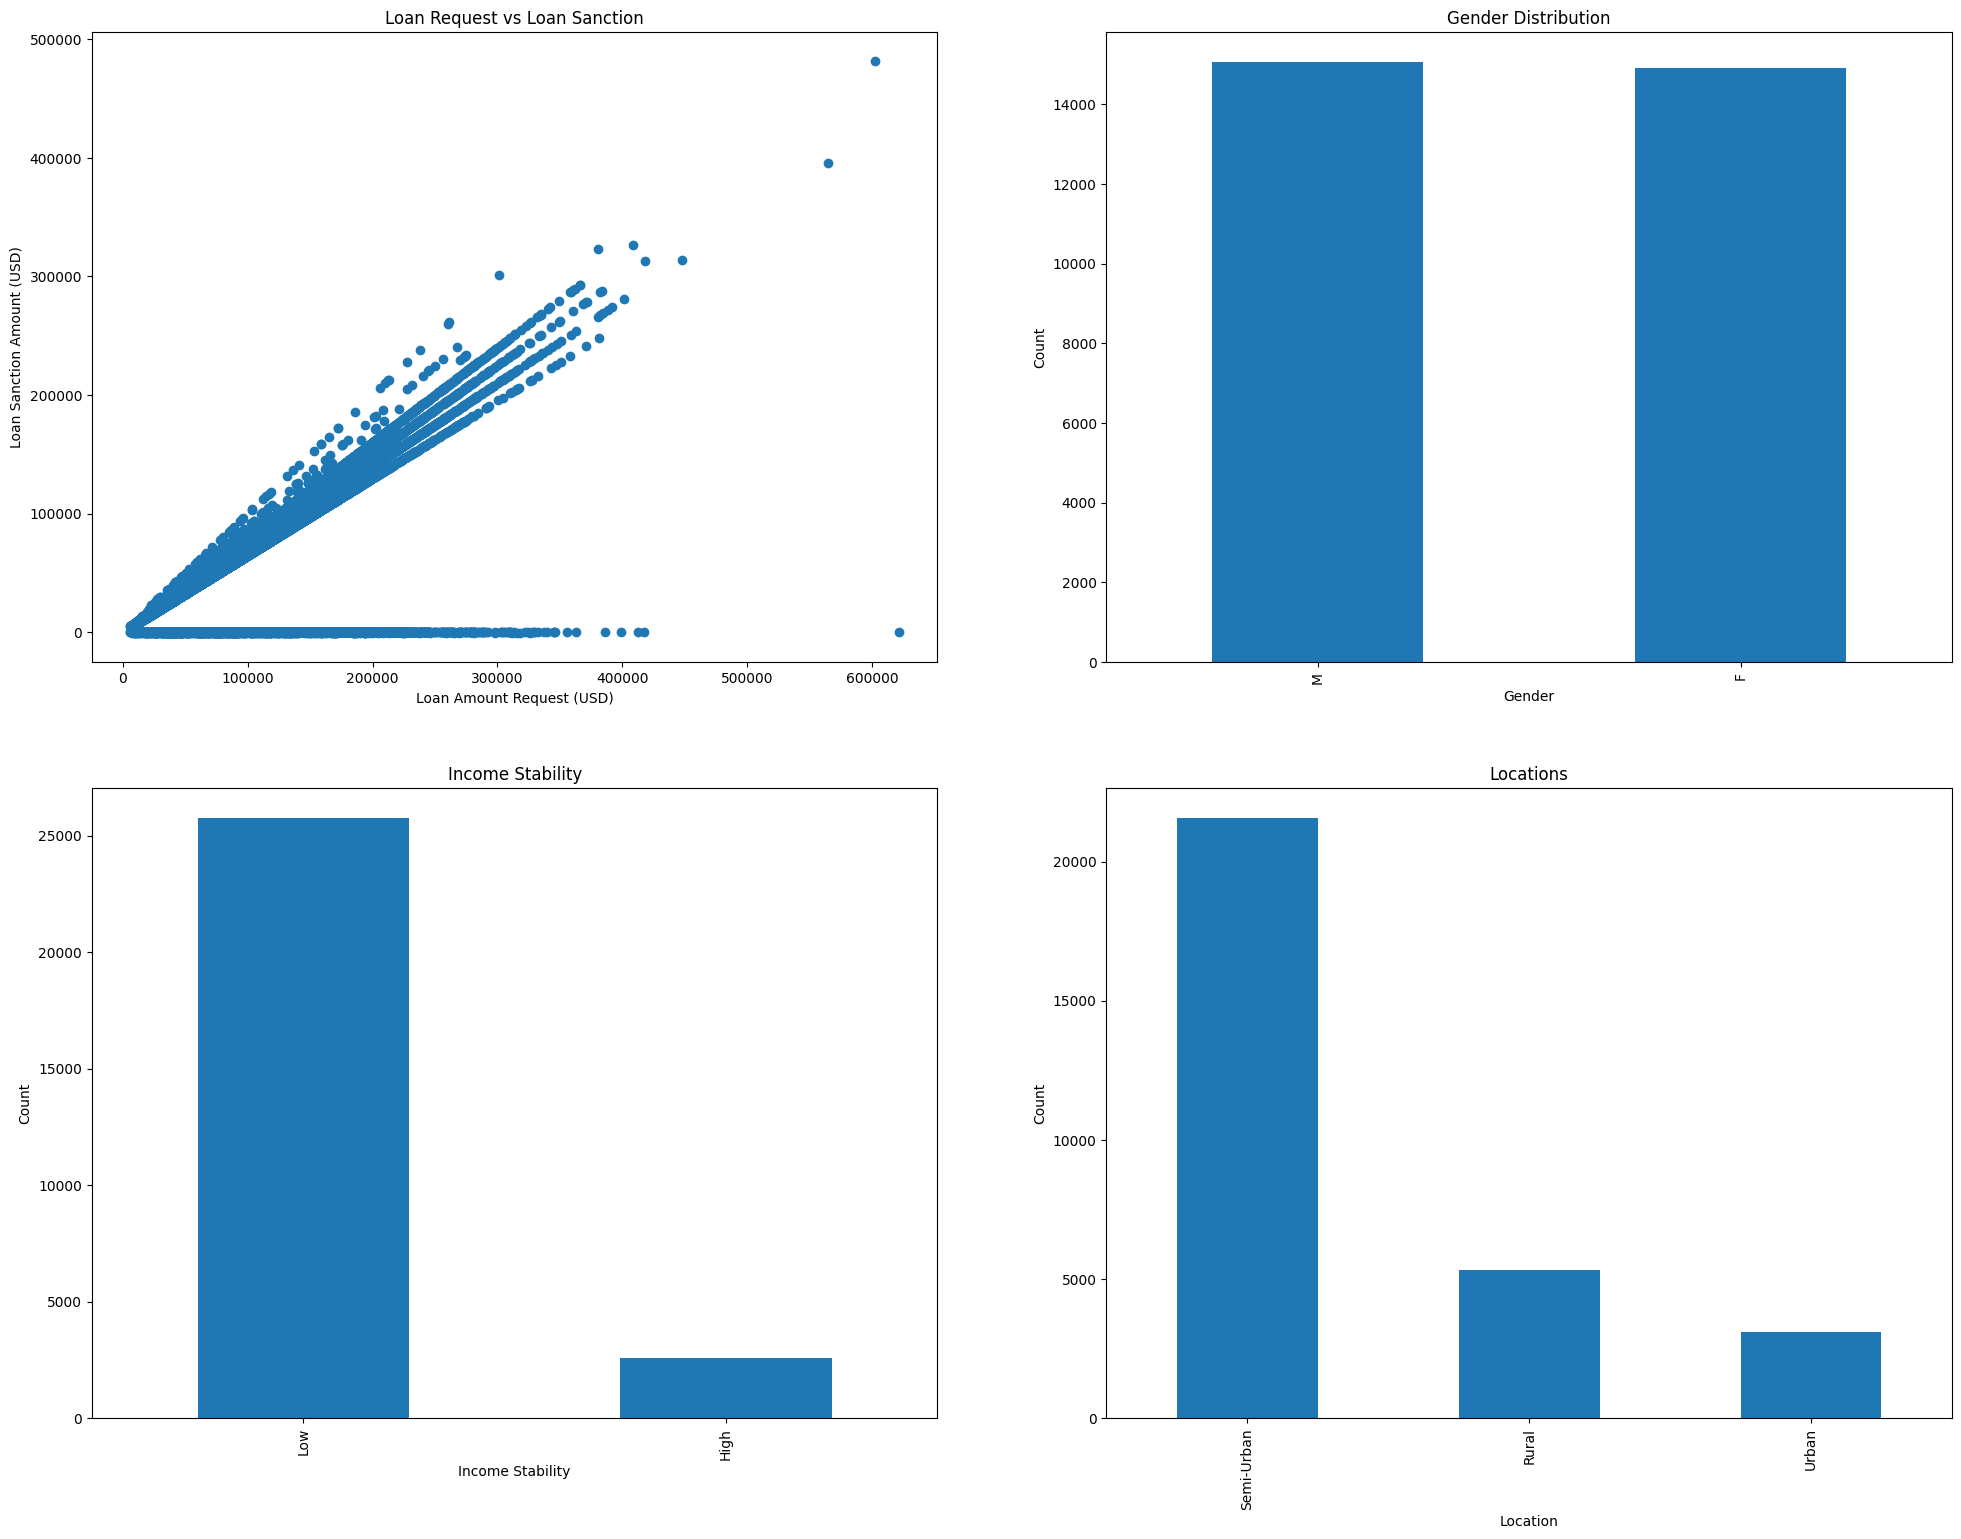

In [289]:
fig, axes = plt.subplots(2, 2, figsize=(24, 18))
axes = axes.flatten()

axes[0].scatter(df["Loan Amount Request (USD)"], df["Loan Sanction Amount (USD)"])
axes[0].set_xlabel("Loan Amount Request (USD)")
axes[0].set_ylabel("Loan Sanction Amount (USD)")
axes[0].set_title("Loan Request vs Loan Sanction")

df["Gender"].value_counts().plot(kind = 'bar', ax = axes[1])
axes[1].set_title("Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")

df["Income Stability"].value_counts().plot(kind = 'bar', ax = axes[2])
axes[2].set_title("Income Stability")
axes[2].set_xlabel("Income Stability")
axes[2].set_ylabel("Count")

df["Location"].value_counts().plot(kind = 'bar', ax = axes[3])
axes[3].set_title("Locations")
axes[3].set_xlabel("Location")
axes[3].set_ylabel("Count")

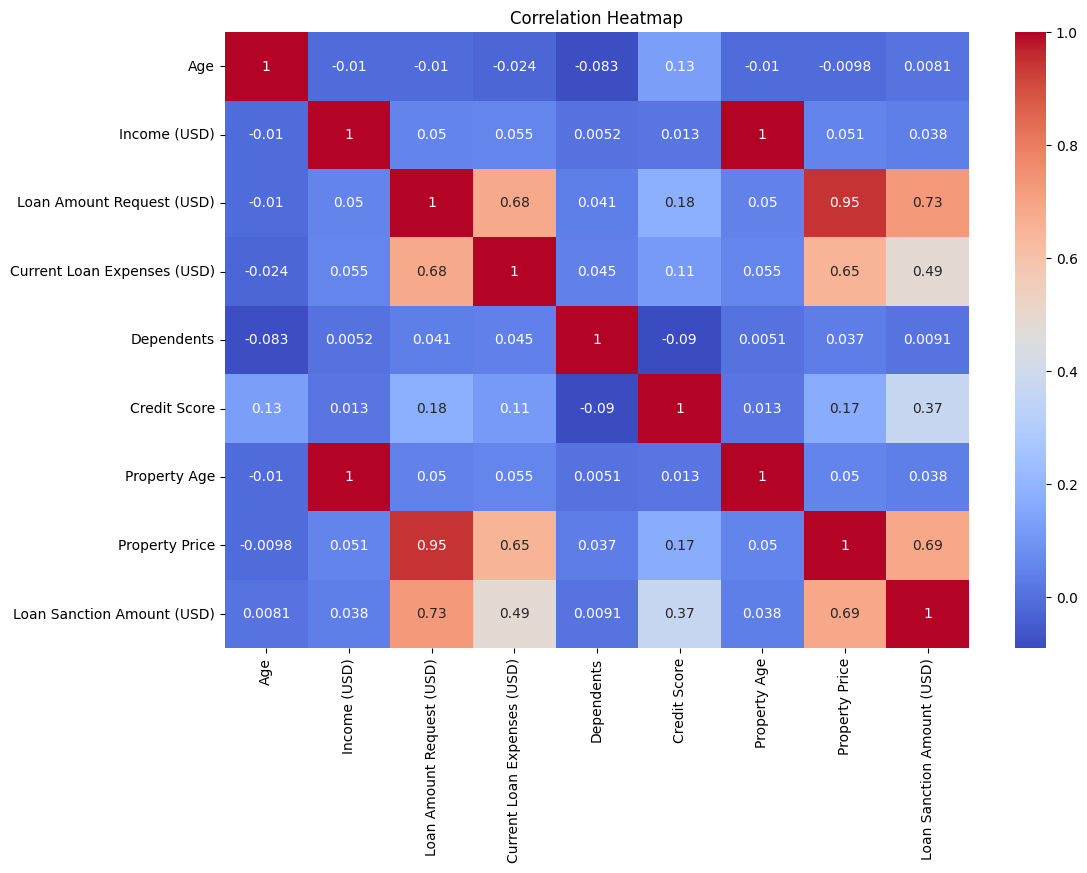

In [290]:
corr = df[numcols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap ="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 2.Iris

In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datasets/Iris.csv")

print("Head (First 5 rows):\n", df.head())

Head (First 5 rows):
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [292]:
print("Shape:", df.shape)

print("Info:")
df.info()

Shape: (150, 6)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [293]:
print("Describe:")
df.describe()

Describe:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


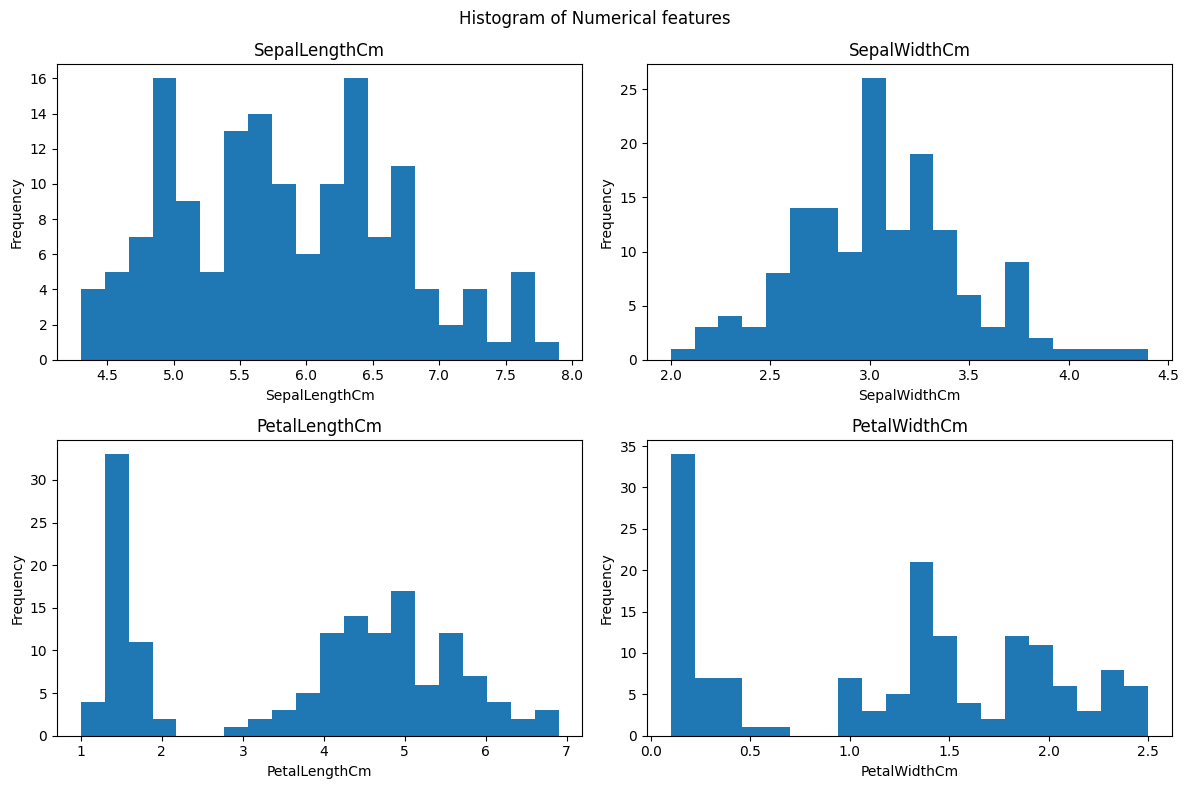

In [294]:
features = [ 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]

plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.suptitle("Histogram of Numerical features")
plt.tight_layout()
plt.show()

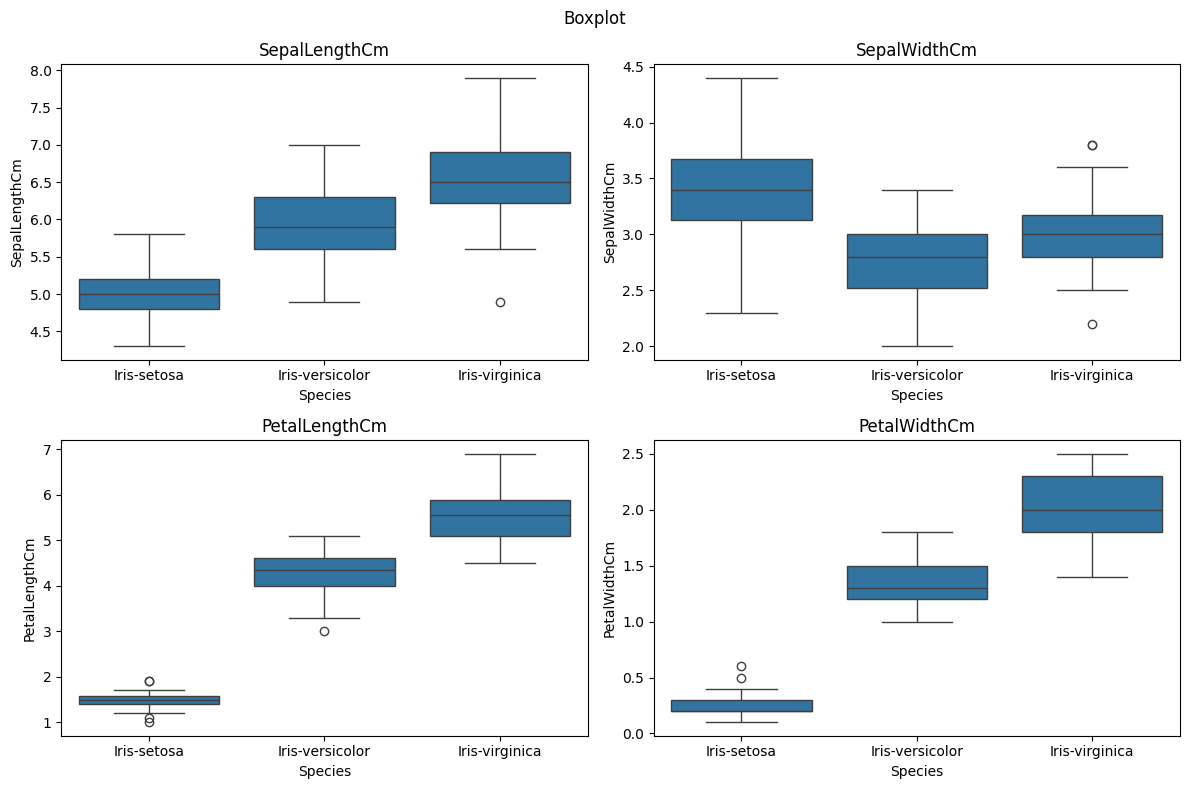

In [295]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Species', y=col, data=df)
    plt.title(col)

plt.suptitle("Boxplot")
plt.tight_layout()
plt.show()

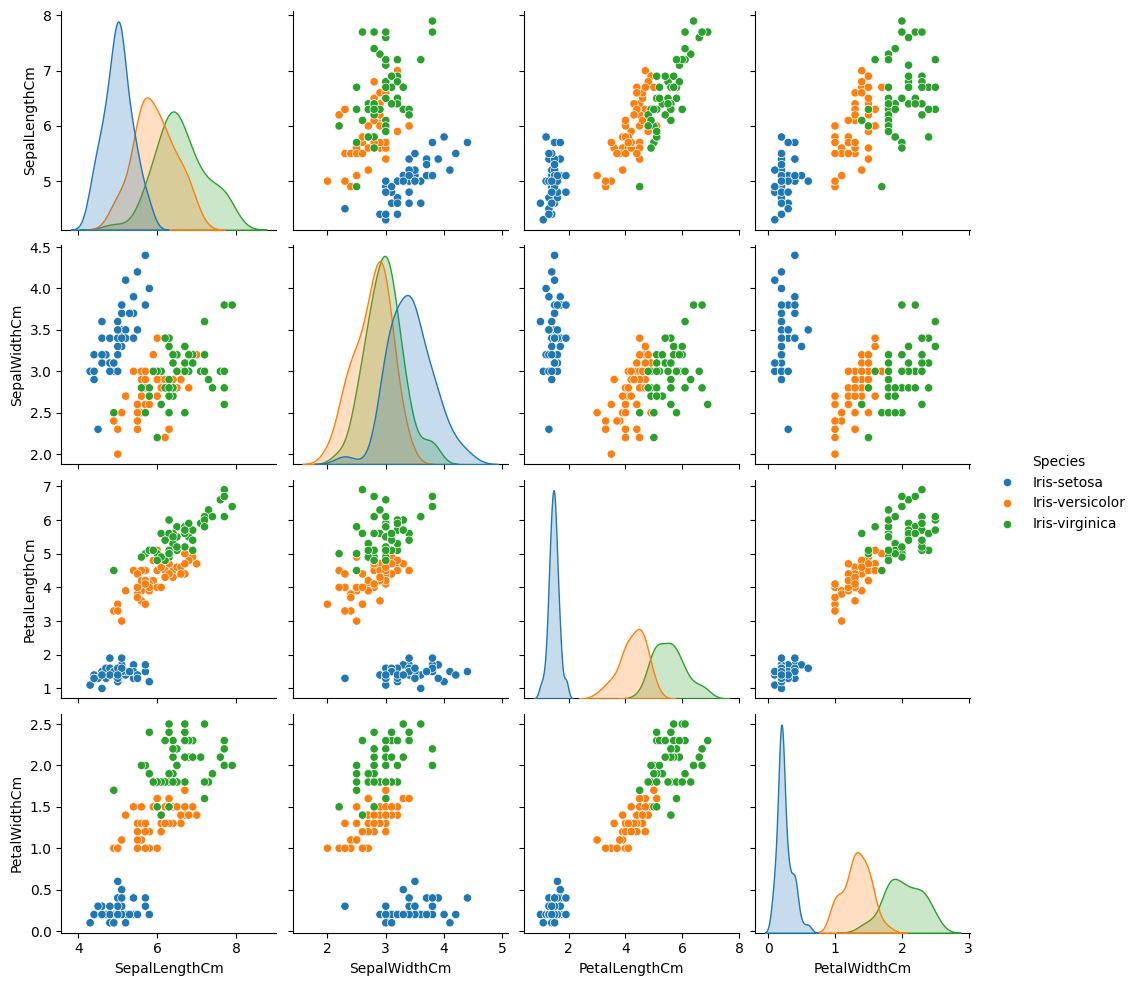

In [296]:
sns.pairplot(df.drop('Id', axis = 1), hue='Species')
plt.show()

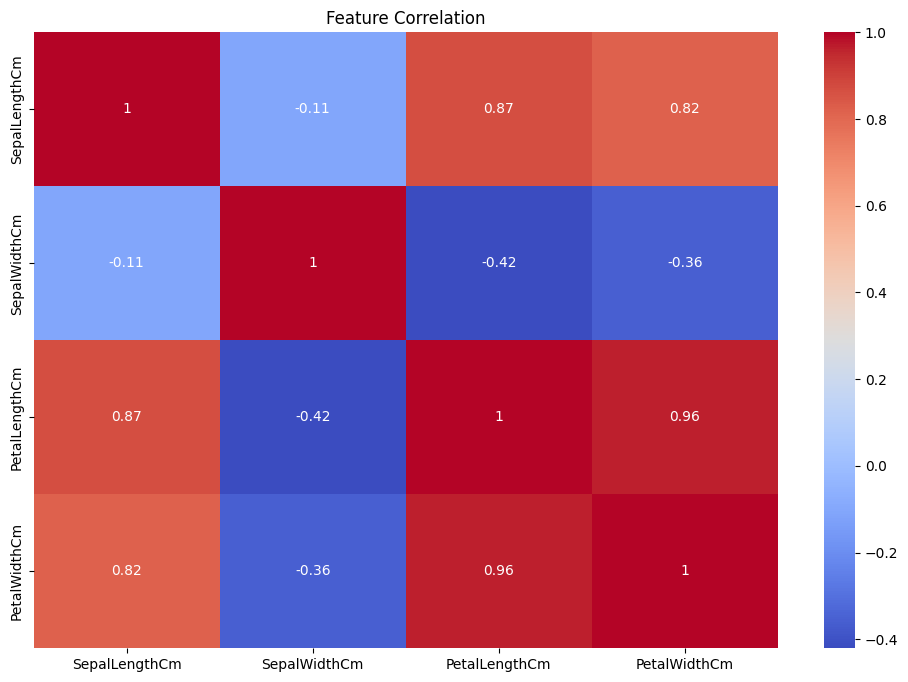

In [297]:
plt.figure(figsize=(12,8))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap ="coolwarm")
plt.title("Feature Correlation")
plt.show()

## 3.Handwritten Character Recognition

In [298]:
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datasets/english.csv")

print("Head (First 5 rows):\n")
df.head()

Head (First 5 rows):



,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [299]:
print("Shape:", df.shape)

print("Info:")
df.info()


Shape: (3410, 2)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   3410 non-null   object
 1   label   3410 non-null   object
dtypes: object(2)
memory usage: 53.4+ KB


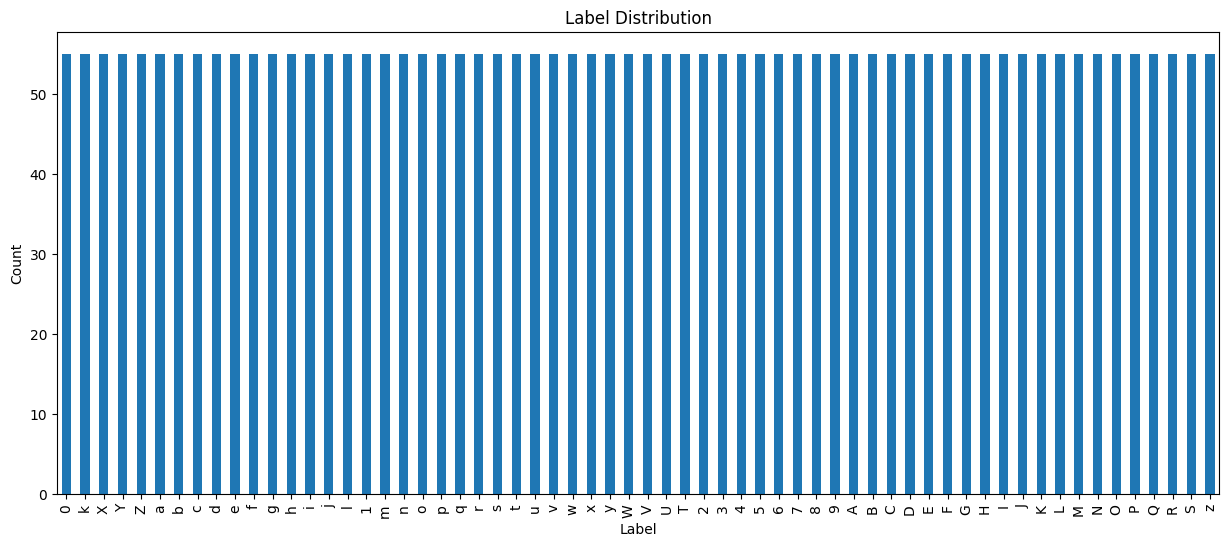

In [300]:

label_counts = df["label"].value_counts()

plt.figure(figsize=(15,6))
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


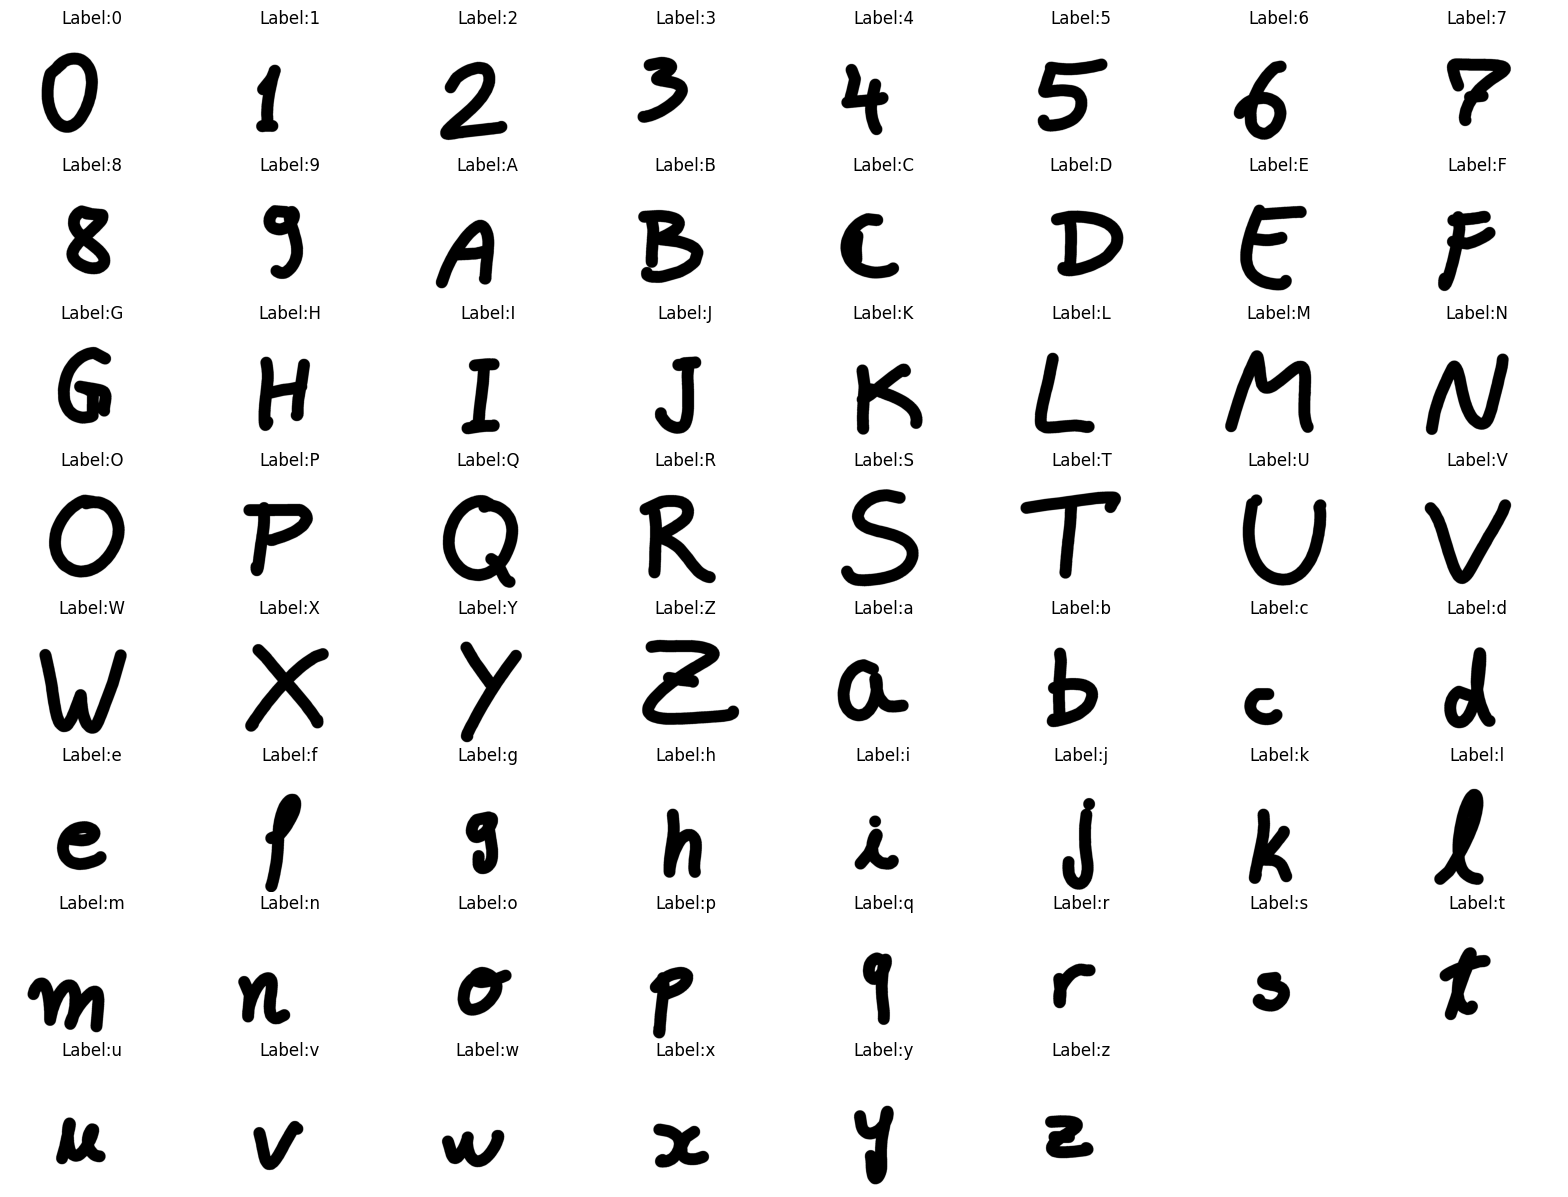

In [301]:
plt.figure(figsize=(20,15))

unique = df.groupby('label').first().reset_index()

for i,row in unique.iterrows():
    img_path = row['image']
    label = row['label']

    img = Image.open(f"datasets/{img_path}")

    plt.subplot(8,8,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Label:{label}")
    
plt.show()

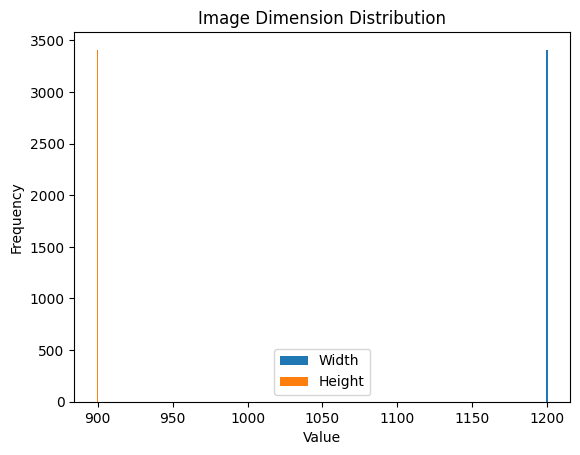

In [302]:
heights = []
widths = []

for img_path in df['image']:
    img = Image.open(f"datasets/{img_path}")
    w,h = img.size
    widths.append(w)
    heights.append(h)

fig, ax = plt.subplots()

ax.hist(widths, bins=1, label="Width")
ax.hist(heights, bins=1, label="Height")

ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
ax.set_title("Image Dimension Distribution")
ax.legend()

plt.show()

## 4. Diabetes

In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datasets/diabetes.csv")

print("Head (First 5 rows):\n")
df.head()

Head (First 5 rows):



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [304]:
print("Shape:", df.shape)

print("Info:")
df.info()

Shape: (768, 9)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [305]:
print("Describe:")
df.describe()

Describe:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [306]:
print("Null content count:")
df.isnull().sum()

Null content count:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

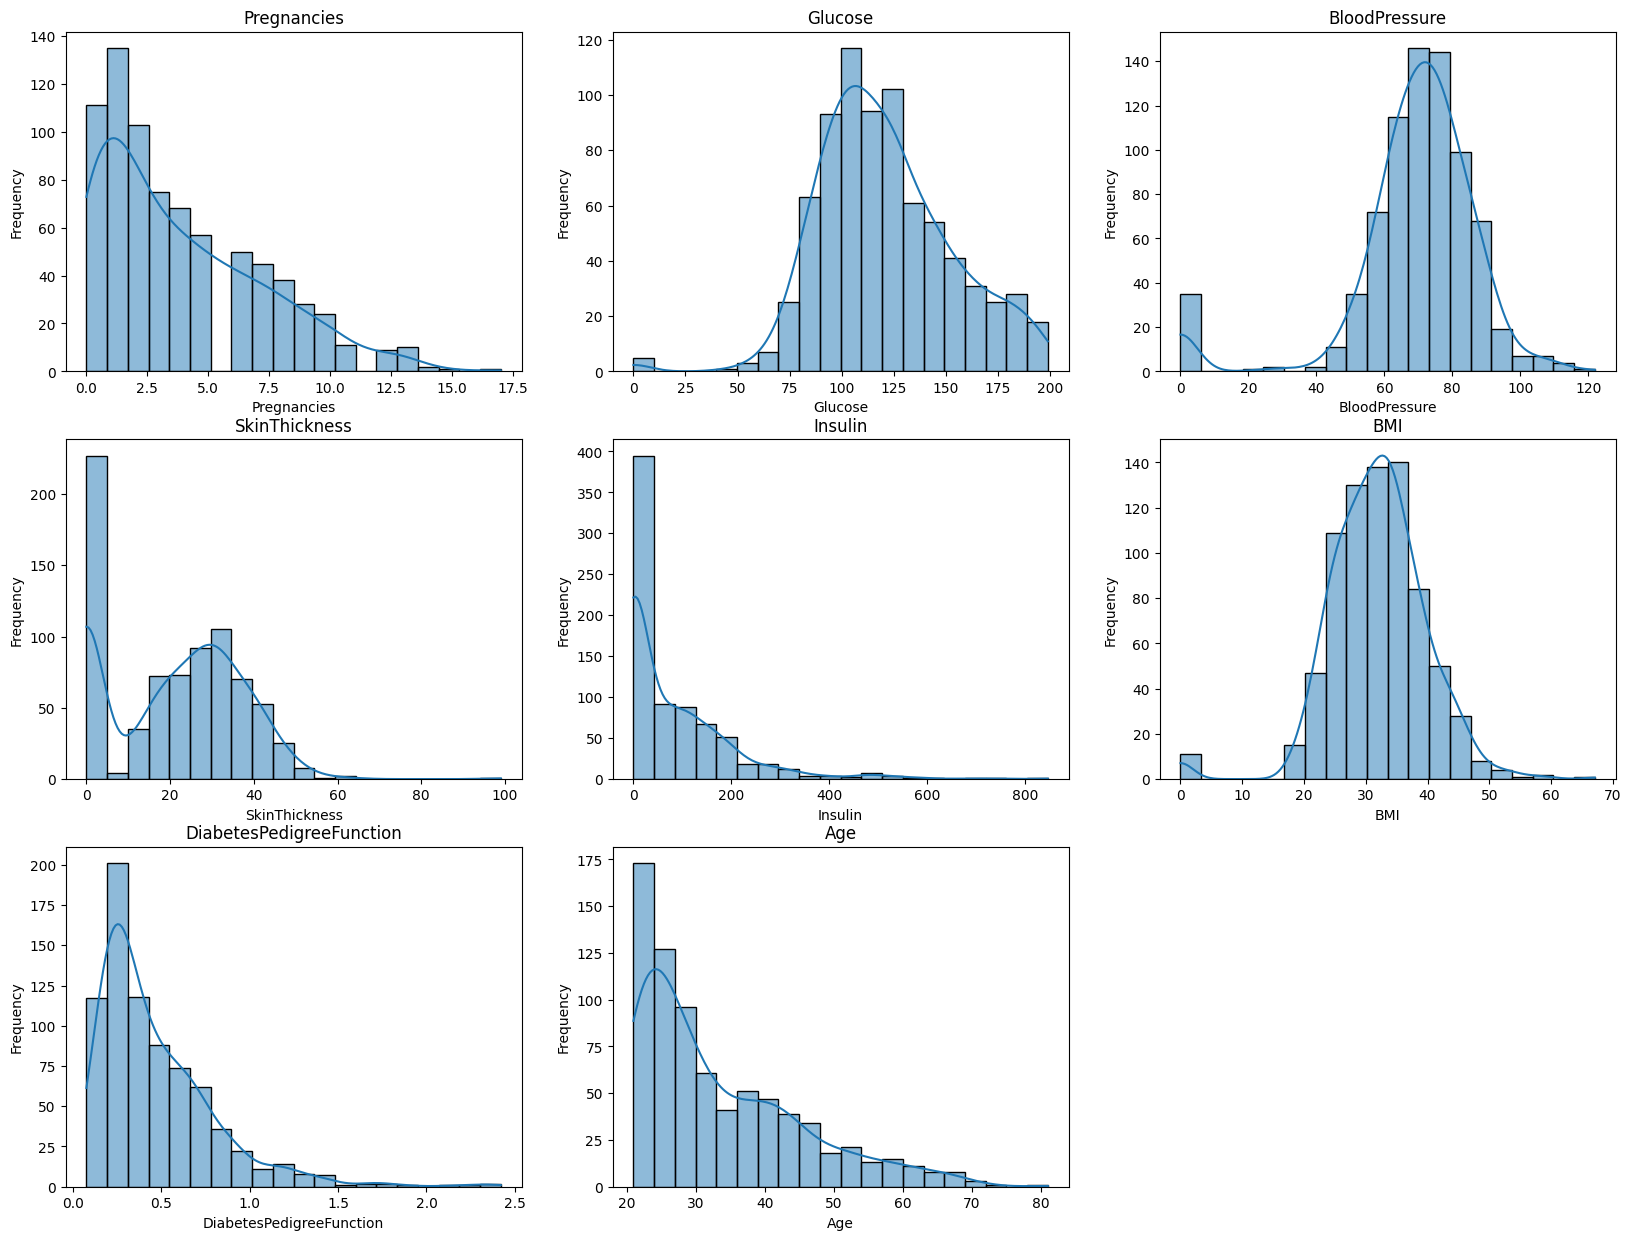

In [307]:
features = df.drop('Outcome', axis=1).columns

plt.figure(figsize=(20, 15))

for i,col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.show()

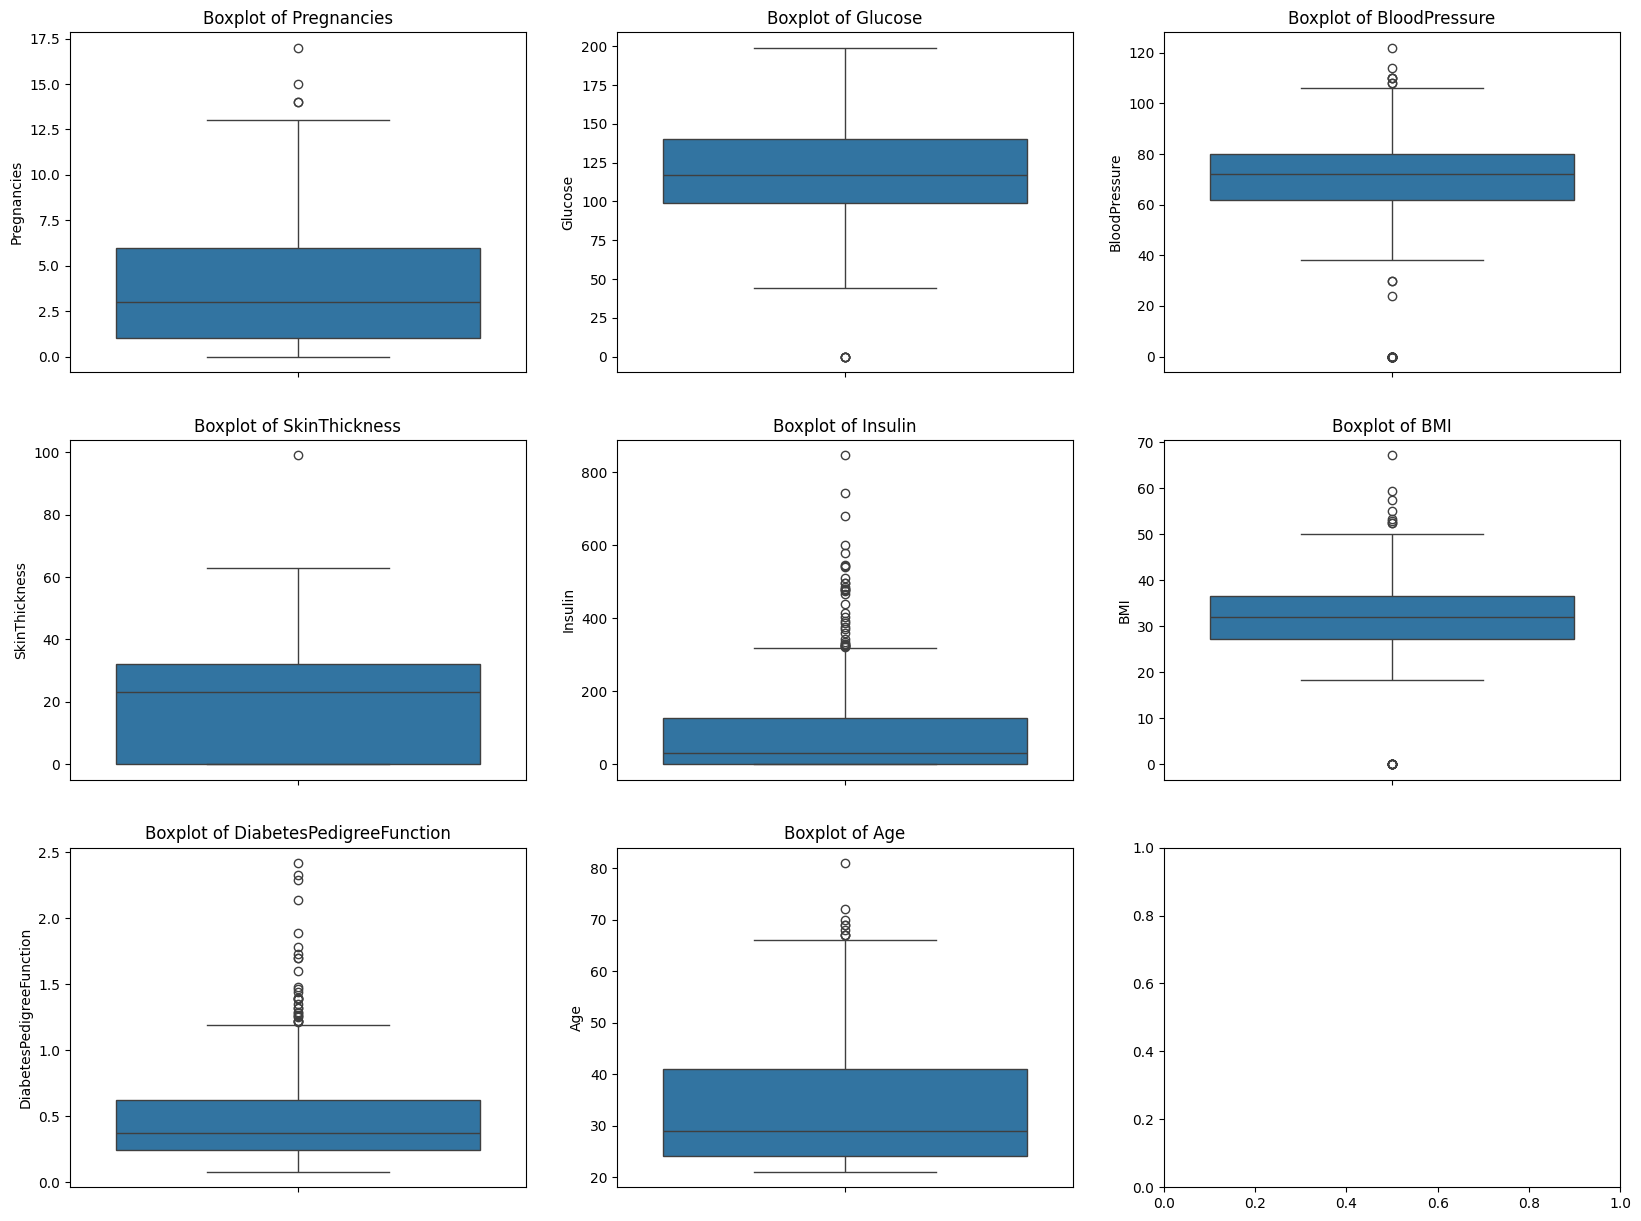

In [308]:
fig,axes = plt.subplots(3, 3, figsize=(20,15))
axes = axes.flatten()

for i,col in enumerate(features):
    sns.boxplot(y=df[col], ax = axes[i])
    axes[i].set_title(f"Boxplot of {col}")

plt.show()

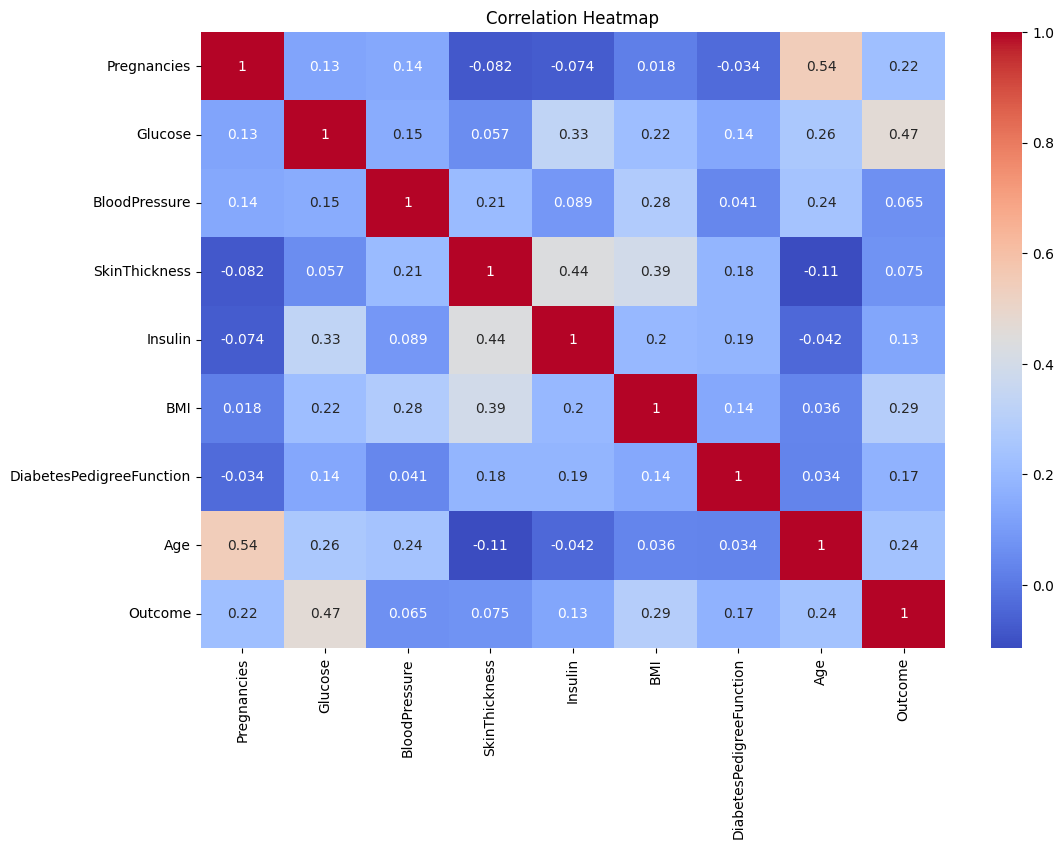

In [309]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap ="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 5.Classification of Email spam

In [310]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("datasets/email.csv")

print("Head (First 5 rows):\n")
df.head()

Head (First 5 rows):



,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [311]:
print("Shape:", df.shape)

print("Info:")
df.info()

Shape: (5572, 2)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [312]:
print("Describe:")
df.describe()

Describe:


,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [313]:
print("Null content count:\n",df.isnull().sum())


print("Count of Spam and Ham:\n",df['Category'].value_counts())


Null content count:
 Category    0
Message     0
dtype: int64
Count of Spam and Ham:
 Category
ham     4825
spam     747
Name: count, dtype: int64


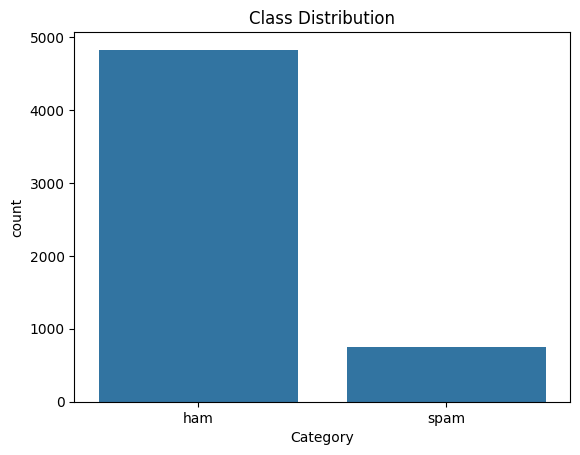

In [314]:
sns.countplot(x=df['Category'])
plt.title("Class Distribution")
plt.show()

In [315]:
df["char_len"] = df["Message"].str.len()
df["word_len"] = df["Message"].str.split().str.len()
print("After add the character length and word length:")
df.head()

After add the character length and word length:


,Category,Message,char_len,word_len
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


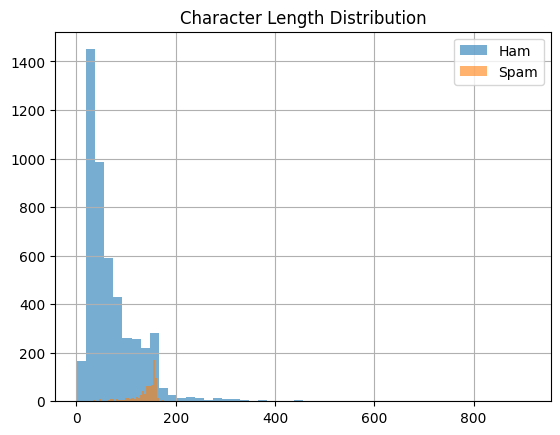

In [316]:
df[df["Category"]=="ham"]["char_len"].hist(alpha=0.6, bins=50)
df[df["Category"]=="spam"]["char_len"].hist(alpha=0.6, bins=50)
plt.legend(["Ham", "Spam"])
plt.title("Character Length Distribution")
plt.show()


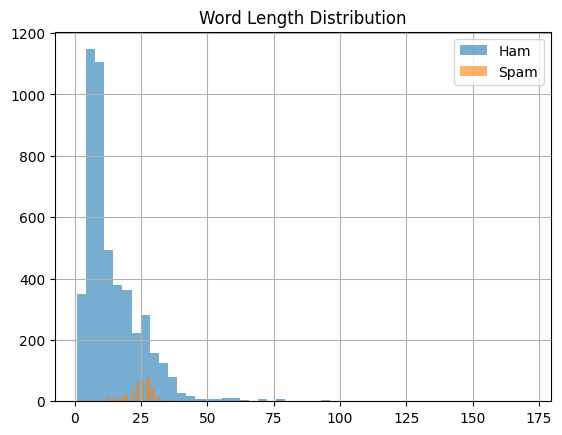

In [317]:
df[df["Category"]=="ham"]["word_len"].hist(alpha=0.6, bins=50)
df[df["Category"]=="spam"]["word_len"].hist(alpha=0.6, bins=50)
plt.legend(["Ham", "Spam"])
plt.title("Word Length Distribution")
plt.show()


In [318]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['clean_text'] = df['Message'].apply(clean_text)
print("After Cleaning:")
df.head()


After Cleaning:


,Category,Message,char_len,word_len,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,29,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,49,11,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,nah i dont think he goes to usf he lives aroun...


In [319]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
common_words = Counter(all_words).most_common(50)
print("Most Common Words:",common_words)


Most Common Words: [('i', 2249), ('to', 2248), ('you', 2128), ('a', 1448), ('the', 1331), ('u', 1154), ('and', 971), ('is', 892), ('in', 889), ('me', 791), ('my', 759), ('for', 711), ('your', 677), ('it', 622), ('of', 622), ('call', 578), ('have', 573), ('on', 536), ('that', 514), ('are', 490), ('now', 479), ('im', 476), ('so', 439), ('not', 436), ('but', 432), ('or', 417), ('at', 405), ('can', 405), ('do', 401), ('ur', 390), ('get', 390), ('be', 385), ('will', 383), ('if', 383), ('with', 382), ('just', 366), ('no', 352), ('we', 351), ('this', 327), ('its', 315), ('up', 307), ('dont', 298), ('when', 287), ('go', 285), ('from', 279), ('ok', 278), ('free', 278), ('ltgt', 276), ('all', 269), ('out', 267)]


In [320]:
spam_words = " ".join(df[df['Category']=="spam"]['clean_text']).split()
ham_words = " ".join(df[df['Category']=="ham"]['clean_text']).split()

print("Spam words most common:\n", Counter(spam_words).most_common(50))
print("\nNot Spam common words:\n", Counter(ham_words).most_common(50))

Spam words most common:
 [('to', 686), ('a', 380), ('call', 347), ('you', 287), ('your', 263), ('free', 219), ('for', 204), ('the', 201), ('now', 190), ('or', 188), ('is', 157), ('u', 153), ('txt', 151), ('on', 145), ('ur', 144), ('have', 132), ('from', 129), ('mobile', 124), ('and', 122), ('text', 121), ('stop', 118), ('claim', 111), ('with', 109), ('reply', 101), ('of', 97), ('prize', 90), ('our', 85), ('this', 84), ('get', 83), ('only', 82), ('are', 80), ('no', 77), ('just', 76), ('p', 73), ('in', 72), ('won', 70), ('nokia', 69), ('new', 69), ('send', 68), ('cash', 62), ('urgent', 62), ('win', 61), ('out', 56), ('service', 55), ('contact', 55), ('please', 54), ('i', 54), ('we', 53), ('be', 52), ('week', 50)]

Not Spam common words:
 [('i', 2195), ('you', 1841), ('to', 1562), ('the', 1130), ('a', 1068), ('u', 1001), ('and', 849), ('in', 817), ('me', 761), ('my', 748), ('is', 735), ('it', 594), ('of', 525), ('for', 507), ('that', 488), ('im', 463), ('have', 441), ('but', 425), ('your'